# RQ3: Human vs. Model bbox annotation

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _rq3_helpers as rq3

SURVEY_CSV = "survey_responses.csv"
EMMT_ROOT = "/home/oliver/PycharmProjects/EMMT_Survey"


## Load survey

In [2]:
df_valid = rq3.load_survey(SURVEY_CSV)


## Case metadata (authoritative model/modality/ground truth per case)

In [3]:
case_meta = rq3.load_case_metadata(EMMT_ROOT)
case_lookup = rq3.load_case_lookup(EMMT_ROOT)
human_iou = rq3.compute_human_task_iou(df_valid, case_lookup, case_meta)
case_df = rq3.case_human_iou(human_iou)
model_iou_cases = rq3.case_model_iou(case_meta)


## Interrater agreement (Krippendorff's alpha, 3-class)

In [4]:
pd.DataFrame(rq3.krippendorff_alpha_by_category(df_valid)).T


,alpha,n_items
overall,0.08651,127.0
multi,-0.00640,34.0
single/multi,0.08137,33.0
single/solo,0.08326,33.0
udacity,0.16814,27.0


## Model-level summary (human IoU, model IoU, acceptance/reject rates)

In [5]:
rq3.model_level_summary(case_df, model_iou_cases)


,human_iou,human_iou_robust,model_iou,accept_rate,reject_image_rate,reject_text_rate,reject_other_rate
model,,,,,,,
intern,0.515736,0.365813,0.099319,0.706147,0.140303,0.115612,0.037937
kimi,0.539557,0.415908,0.011724,0.758663,0.107382,0.086934,0.047021
nemotron,0.509684,0.306914,0.165347,0.602238,0.163837,0.170139,0.063786
qwen,0.467189,0.303440,0.243298,0.632716,0.114841,0.216435,0.036008


## Human vs. model Mean IoU, grouped by model

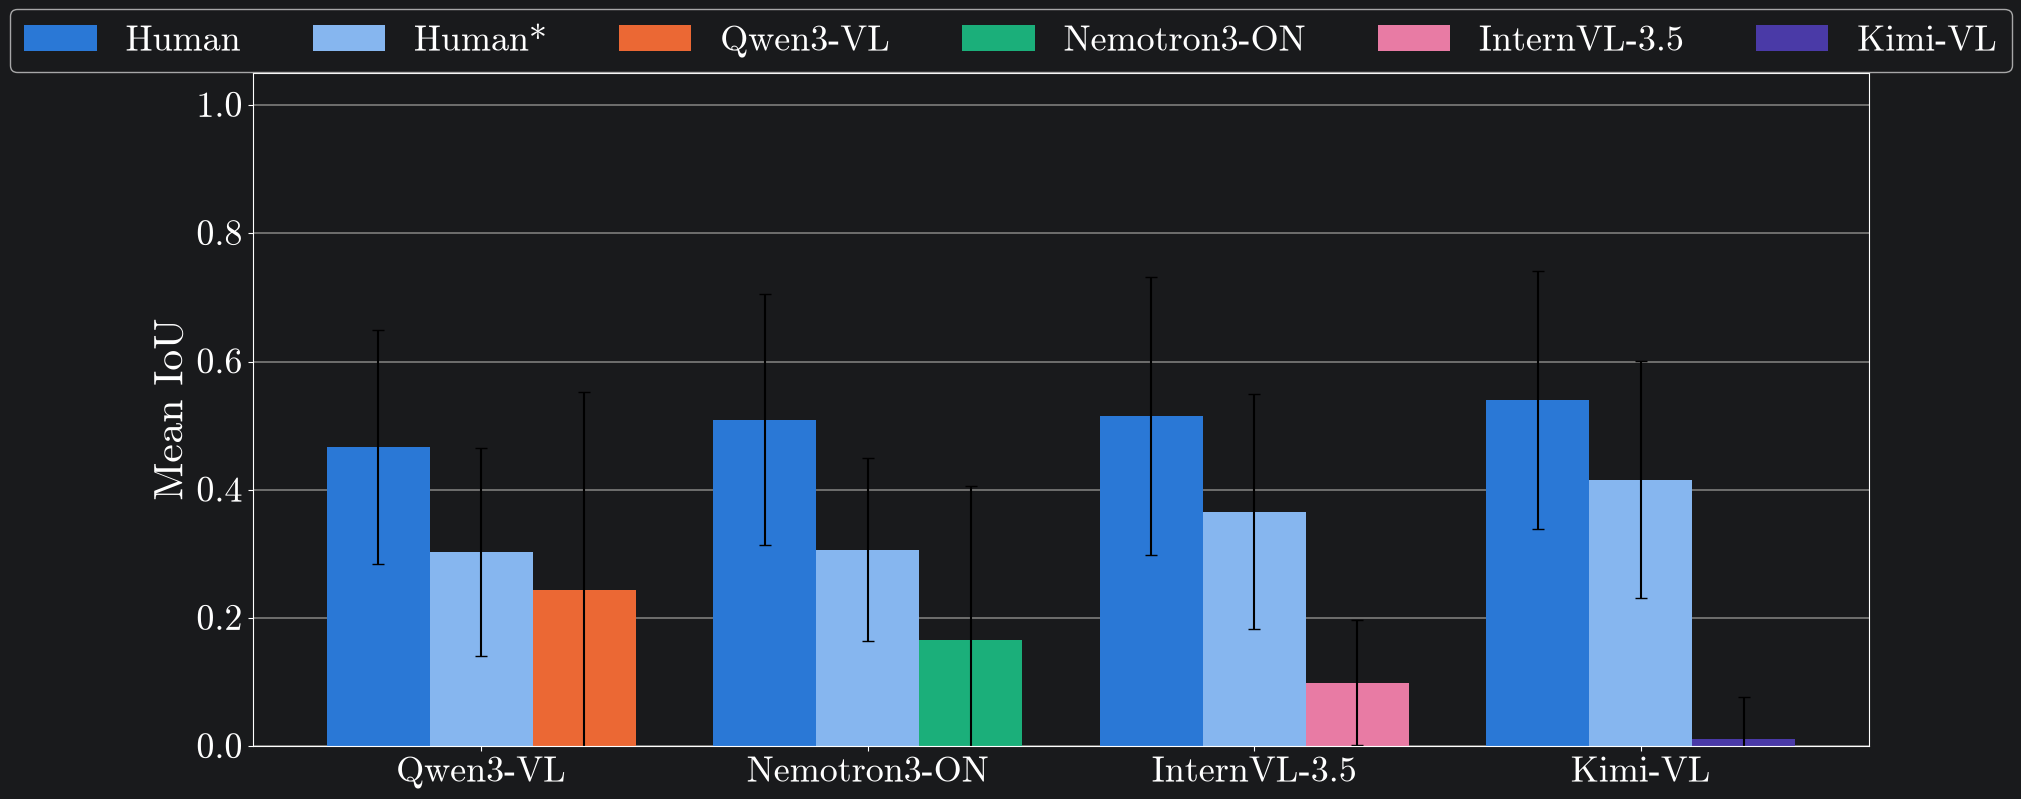

In [6]:
from matplotlib.patches import Patch

MODEL_ORDER = rq3.MODELS
MODEL_COLORS = {"qwen": "#eb6834", "nemotron": "#1baf7a", "intern": "#e87ba4", "kimi": "#4a3aa7"}
HUMAN_COLOR, HUMAN_ADJ_COLOR = "#2a78d6", "#86b6ef"

FONT = {
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman", "DejaVu Serif"],
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 28,
    "axes.titlesize": 34,
    "axes.labelsize": 30,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 26,
}

stats = case_df.groupby("model").agg(
    human_mean=("iou_given_accept", "mean"),
    human_std=("iou_given_accept", "std"),
    human_n=("iou_given_accept", "count"),
    robust_mean=("iou_robust", "mean"),
    robust_std=("iou_robust", "std"),
)
model_stats = model_iou_cases.groupby("model")["iou"].agg(model_mean="mean", model_std="std", model_n="count")
stats = stats.join(model_stats)

with plt.rc_context(FONT):
    fig, ax = plt.subplots(figsize=(4.5 * len(MODEL_ORDER), 8))

    x = np.arange(len(MODEL_ORDER))
    bar_w = 0.8 / 3
    series = [
        ("Human", "human_mean", "human_std", "human_n", HUMAN_COLOR),
        ("Human*", "robust_mean", "robust_std", None, HUMAN_ADJ_COLOR),
        ("Model", "model_mean", "model_std", "model_n", None),
    ]
    for i, (name, mean_col, std_col, n_col, color) in enumerate(series):
        vals = [stats.loc[m, mean_col] for m in MODEL_ORDER]
        errs = [stats.loc[m, std_col] for m in MODEL_ORDER]
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER] if color is None else color
        ax.bar(x + (i - 1) * bar_w, vals, width=bar_w, yerr=errs, capsize=4, color=colors, zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels([rq3.MODEL_LABELS[m] for m in MODEL_ORDER])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean IoU")
    ax.grid(axis="y", color="#e1e0d9", linewidth=1.2, zorder=0)
    ax.set_axisbelow(True)

    legend_handles = [
        Patch(facecolor=HUMAN_COLOR, label="Human"),
        Patch(facecolor=HUMAN_ADJ_COLOR, label="Human*"),
    ] + [Patch(facecolor=MODEL_COLORS[m], label=rq3.MODEL_LABELS[m]) for m in MODEL_ORDER]
    fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles), bbox_to_anchor=(0.5, 1.05))
    fig.tight_layout()
    fig.savefig("figures/rq3_human_vs_model_iou.pdf", dpi=200, bbox_inches="tight")
    plt.show()
